✅ Optimal Taylor Coefficients Found:
a0 = 0.996913
a1 = 0.788354
a2 = 0.220532
a3 = 0.337706
a4 = 0.427270

Mean Squared Error: 0.0063119011

📘 True Taylor Coefficients (e^x):
a0 = 1.000000
a1 = 1.000000
a2 = 0.500000
a3 = 0.166667
a4 = 0.041667


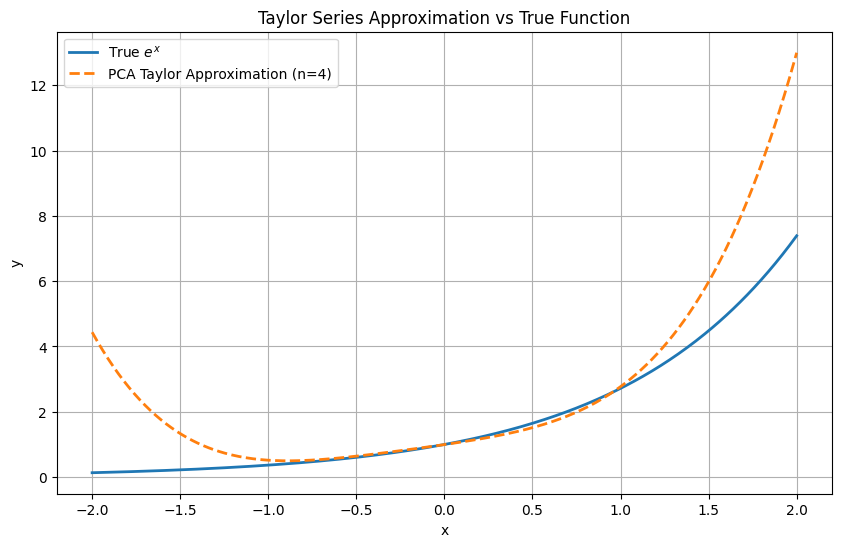

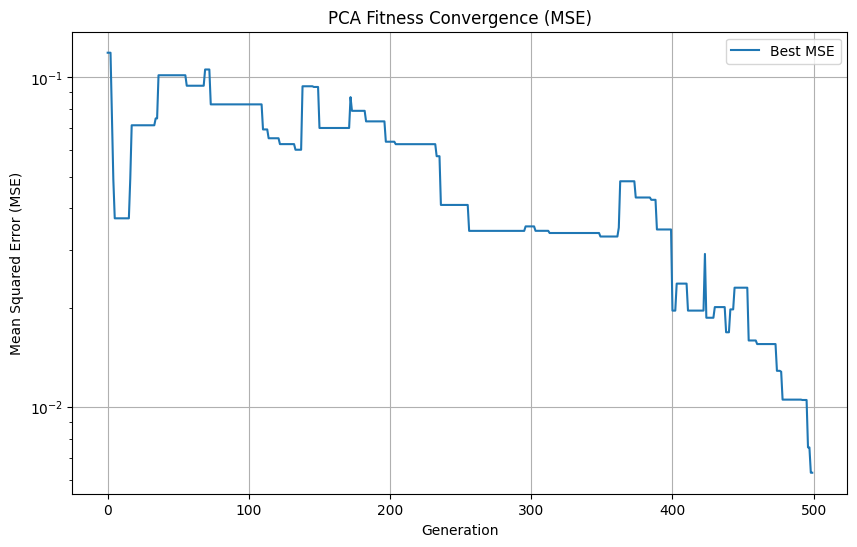

In [10]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

# -------------------------------
# Problem Setup
# -------------------------------
def target_function(x):
    return np.exp(x)

def taylor_series(x, coeffs):
    return sum(coeffs[i] * (x ** i) for i in range(len(coeffs)))

def mse_error(coeffs, xs):
    ys_true = target_function(xs)
    ys_pred = taylor_series(xs, coeffs)
    return np.mean((ys_true - ys_pred) ** 2)

# -------------------------------
# PCA Functions
# -------------------------------
def random_solution(n_terms, bounds):
    return np.array([random.uniform(bounds[0], bounds[1]) for _ in range(n_terms)])

def mutate(coeffs, bounds, mutation_rate=0.2):
    new = coeffs.copy()
    for i in range(len(coeffs)):
        if random.random() < mutation_rate:
            new[i] += random.uniform(-0.1, 0.1)
            new[i] = np.clip(new[i], bounds[0], bounds[1])
    return new

def get_neighbors(grid, i, j):
    nrows, ncols = grid.shape[0], grid.shape[1]
    neighbors = []
    if i > 0:
        neighbors.append(grid[i-1][j])
    if i < nrows-1:
        neighbors.append(grid[i+1][j])
    if j > 0:
        neighbors.append(grid[i][j-1])
    if j < ncols-1:
        neighbors.append(grid[i][j+1])
    return neighbors

# -------------------------------
# Parallel Cellular Algorithm
# -------------------------------
def parallel_cellular_algorithm_2D(nrows=7, ncols=7, n_terms=4, bounds=(-2, 2),
                                   Tmax=500, lam=0.3, p_mut=0.1):  # Increased Tmax for more epochs
    xs = np.linspace(-1, 1, 200)

    # Step 1: Initialize population
    grid = np.empty((nrows, ncols), dtype=object)
    fitness = np.zeros((nrows, ncols))
    for i in range(nrows):
        for j in range(ncols):
            grid[i][j] = random_solution(n_terms + 1, bounds)
            fitness[i][j] = -mse_error(grid[i][j], xs)

    # Step 2: Iterative Optimization
    best_fitness_history = []  # To store the best fitness over generations
    for t in range(Tmax):
        new_grid = np.empty_like(grid)
        current_best_fitness = float('-inf')
        for i in range(nrows):
            for j in range(ncols):
                neighbors = get_neighbors(grid, i, j)
                best_neighbor = max(neighbors, key=lambda c: -mse_error(c, xs))
                current = grid[i][j]

                # Diffusion update (Von Neumann neighborhood)
                current_fitness = -mse_error(current, xs)
                best_neighbor_fitness = -mse_error(best_neighbor, xs)

                if best_neighbor_fitness > current_fitness:
                    diff = np.zeros_like(current)
                    for n in neighbors:
                        diff += (n - current)
                    new = current + lam * diff / len(neighbors)
                else:
                    new = current

                # Mutation
                if random.random() < p_mut:
                    new = mutate(new, bounds)

                new_grid[i][j] = new

                # Track the best fitness in this generation
                new_fitness = -mse_error(new, xs)
                if new_fitness > current_best_fitness:
                    current_best_fitness = new_fitness

        grid = new_grid
        best_fitness_history.append(-current_best_fitness)  # Store best MSE (positive value)

    # Step 3: Find best solution
    all_cells = [grid[i][j] for i in range(nrows) for j in range(ncols)]
    best = min(all_cells, key=lambda c: mse_error(c, xs))
    best_mse = mse_error(best, xs)

    return best, best_mse, best_fitness_history

# -------------------------------
# Run the algorithm and Plotting
# -------------------------------
if __name__ == "__main__":
    best_coeffs, best_error, fitness_history = parallel_cellular_algorithm_2D()

    print("✅ Optimal Taylor Coefficients Found:")
    for i, a in enumerate(best_coeffs):
        print(f"a{i} = {a:.6f}")

    print(f"\nMean Squared Error: {best_error:.10f}")

    # Compare true vs optimized coefficients (for e^x centered at 0)
    n_terms = len(best_coeffs) - 1
    true_coeffs = [1/math.factorial(i) for i in range(n_terms + 1)]
    print("\n📘 True Taylor Coefficients (e^x):")
    for i, a in enumerate(true_coeffs):
        print(f"a{i} = {a:.6f}")

    # --- Plotting ---

    # 1. Plot the target function and the Taylor approximation
    xs_plot = np.linspace(-2, 2, 400)  # Wider range for plotting
    ys_true_plot = target_function(xs_plot)
    ys_pred_plot = taylor_series(xs_plot, best_coeffs)

    plt.figure(figsize=(10, 6))
    plt.plot(xs_plot, ys_true_plot, label='True $e^x$', linewidth=2)
    plt.plot(xs_plot, ys_pred_plot, label=f'PCA Taylor Approximation (n={n_terms})', linestyle='--', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Taylor Series Approximation vs True Function')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Plot the fitness history (MSE convergence)
    plt.figure(figsize=(10, 6))
    plt.plot(fitness_history, label='Best MSE')
    plt.xlabel('Generation')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('PCA Fitness Convergence (MSE)')
    plt.yscale('log')  # Log scale often helps visualize convergence
    plt.legend()
    plt.grid(True)
    plt.show()
